<a href="https://colab.research.google.com/github/FeDevPolis/QuantumXSchool/blob/main/Session3%264.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-aer matplotlib numpy pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.1 MB/s eta 0:00:00



### 📊 1. Single-Qubit Gate Order Comparison

* **Circuit A $(H \rightarrow X \rightarrow Z)$**
  * **Statevector:** `[np.complex128(0.7071+0j), np.complex128(-0.7071+0j)]`
  * **Counts:** `{'0': 494, '1': 530}`

* **Circuit B $(Z \rightarrow X \rightarrow H)$**
  * **Statevector:** `[np.complex128(0.7071+0j), np.complex128(-0.7071+0j)]`
  * **Counts:** `{'0': 515, '1': 509}`
---


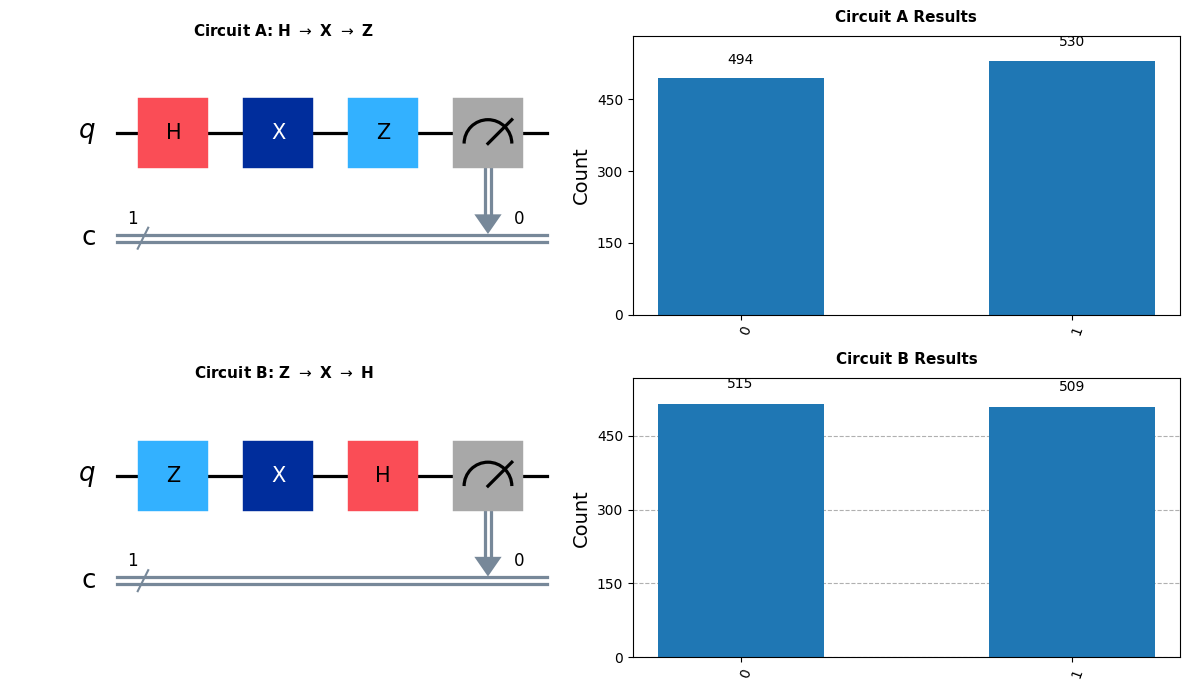


### 📊 2. Custom Single-Qubit Circuit

* **Gate Sequence:** $H \rightarrow X \rightarrow H \rightarrow T$
* **Statevector:** `[np.complex128(1+0j), np.complex128(0j)]`
* **Measurement Counts:** `{'0': 1024, '1': 0}`
---


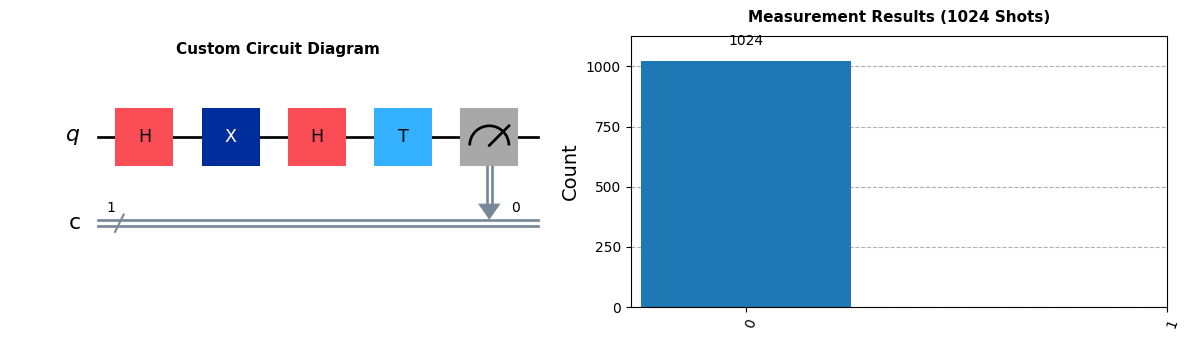


### 📊 3. Two-Qubit Systems Comparison

* **Circuit A (Independent Superposition)**
  * **Statevector:** `[np.complex128(0.5+0j), np.complex128(0.5+0j), np.complex128(0.5+0j), np.complex128(0.5+0j)]`
  * **Counts:** `{'00': 295, '01': 260, '10': 222, '11': 247}`

* **Circuit B (Entangled State)**
  * **Statevector:** `[np.complex128(0.7071+0j), np.complex128(0j), np.complex128(0j), np.complex128(0.7071+0j)]`
  * **Counts:** `{'00': 512, '01': 0, '10': 0, '11': 512}`
---


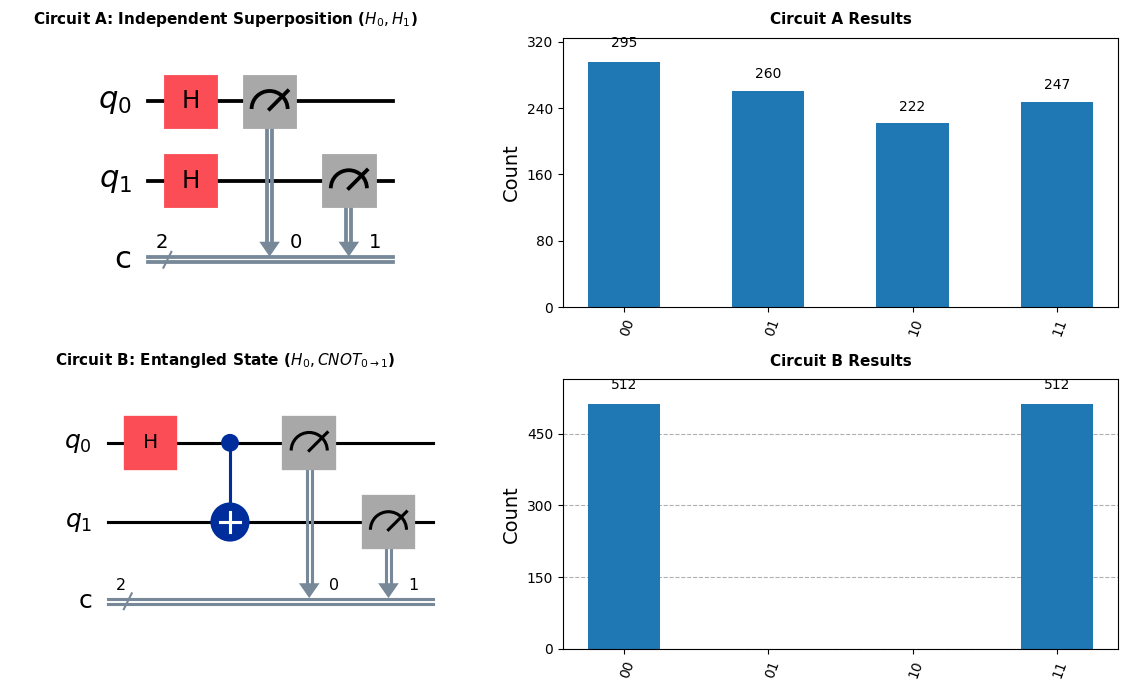


### 📊 4. Bell State Challenge ($|\Psi^+\rangle$)

* **Target Bell State:** $|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}$
* **Statevector:** `[np.complex128(0j), np.complex128(0.7071+0j), np.complex128(0.7071+0j), np.complex128(0j)]`
* **Measurement Counts:** `{'00': 0, '01': 500, '10': 524, '11': 0}`
---


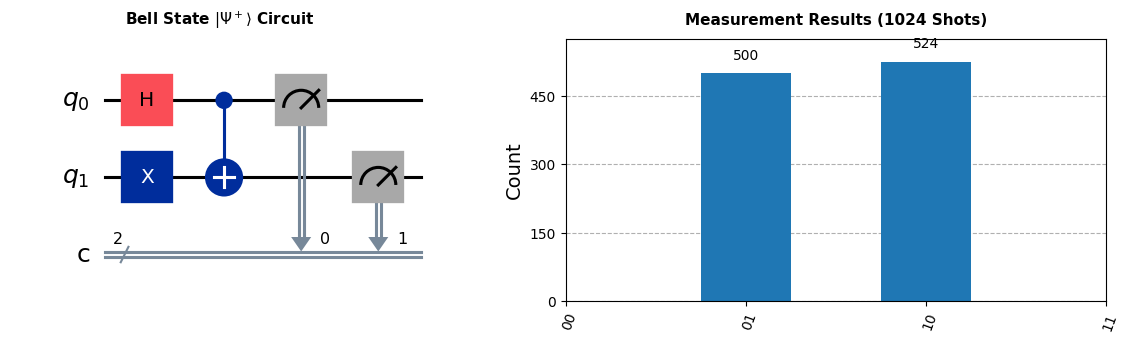

### 📊 5. Explore the Four Bell States
---

**State $|\Phi^+\rangle$:** Statevector = `[np.complex128(0.707+0j), np.complex128(0j), np.complex128(0j), np.complex128(0.707+0j)]` | Counts = `{'00': 507, '01': 0, '10': 0, '11': 517}`

**State $|\Phi^-\rangle$:** Statevector = `[np.complex128(0.707+0j), np.complex128(0j), np.complex128(0j), np.complex128(0.707+0j)]` | Counts = `{'00': 536, '01': 0, '10': 0, '11': 488}`

**State $|\Psi^+\rangle$:** Statevector = `[np.complex128(0j), np.complex128(0.707+0j), np.complex128(0.707+0j), np.complex128(0j)]` | Counts = `{'00': 0, '01': 496, '10': 528, '11': 0}`

**State $|\Psi^-\rangle$:** Statevector = `[np.complex128(0j), np.complex128(0.707+0j), np.complex128(0.707+0j), np.complex128(0j)]` | Counts = `{'00': 0, '01': 526, '10': 498, '11': 0}`

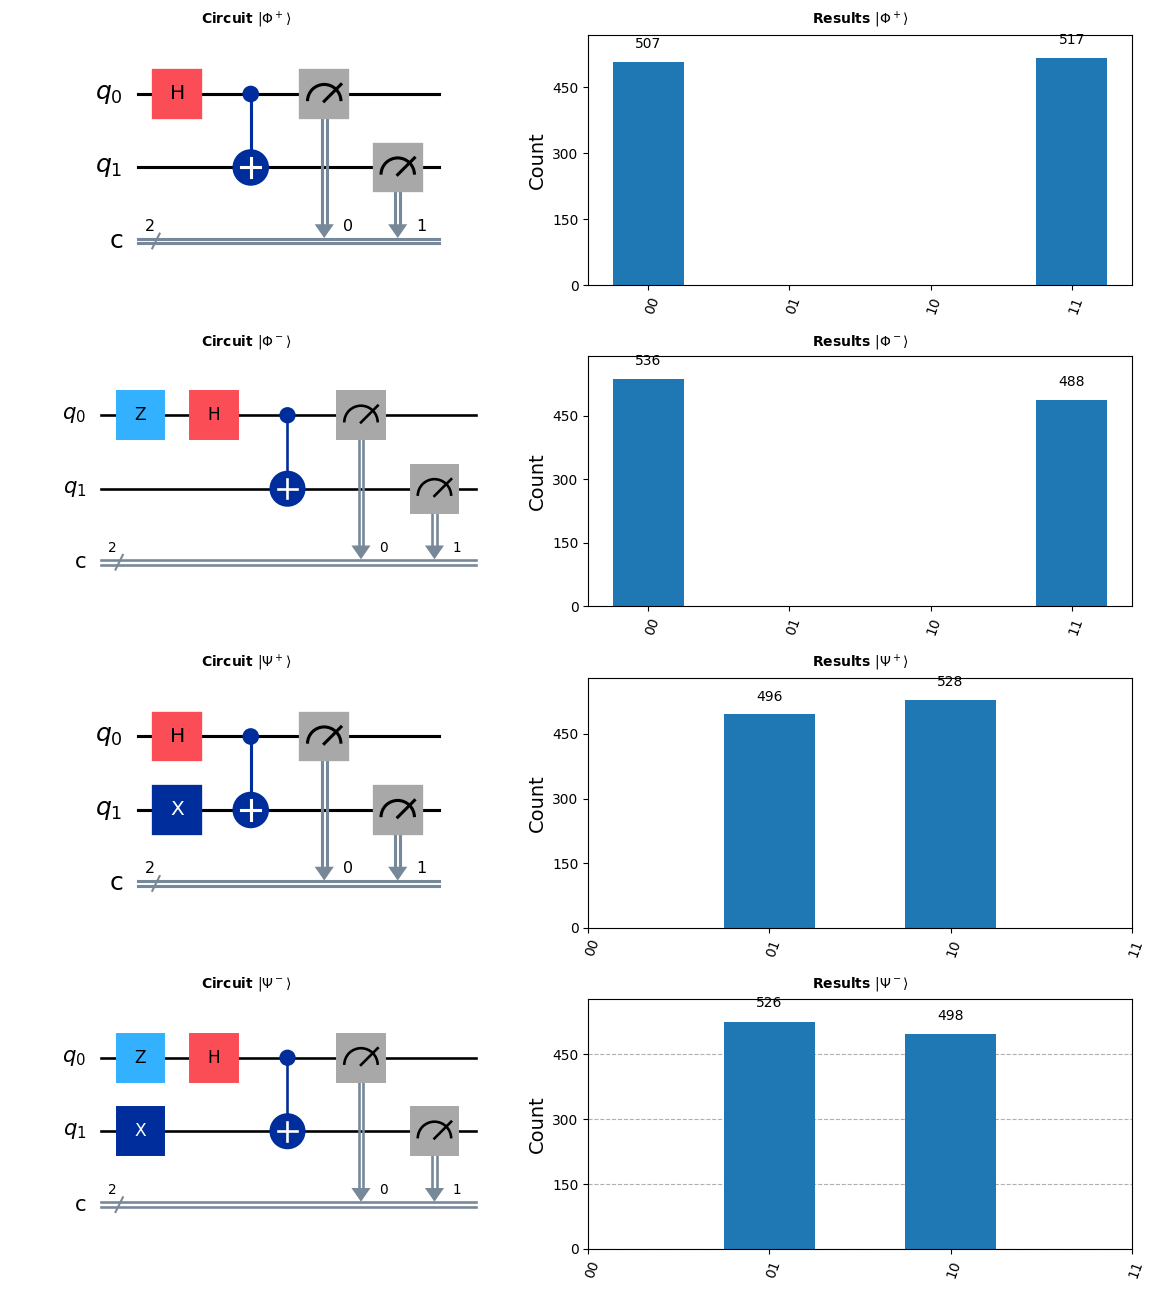

### 📊 6. Entanglement Detective Investigation
---

**Circuit 1 (Entangled):** Statevector = `[np.complex128(0.707+0j), np.complex128(0j), np.complex128(0j), np.complex128(0.707+0j)]` | Counts = `{'00': 512, '01': 0, '10': 0, '11': 512}`

**Circuit 2 (Separable):** Statevector = `[np.complex128(0.5+0j), np.complex128(0.5+0j), np.complex128(0.5+0j), np.complex128(0.5+0j)]` | Counts = `{'00': 271, '01': 243, '10': 261, '11': 249}`

**Circuit 3 (Separable):** Statevector = `[np.complex128(0.5+0j), np.complex128(-0.5+0j), np.complex128(0.5+0j), np.complex128(-0.5+0j)]` | Counts = `{'00': 256, '01': 259, '10': 252, '11': 257}`

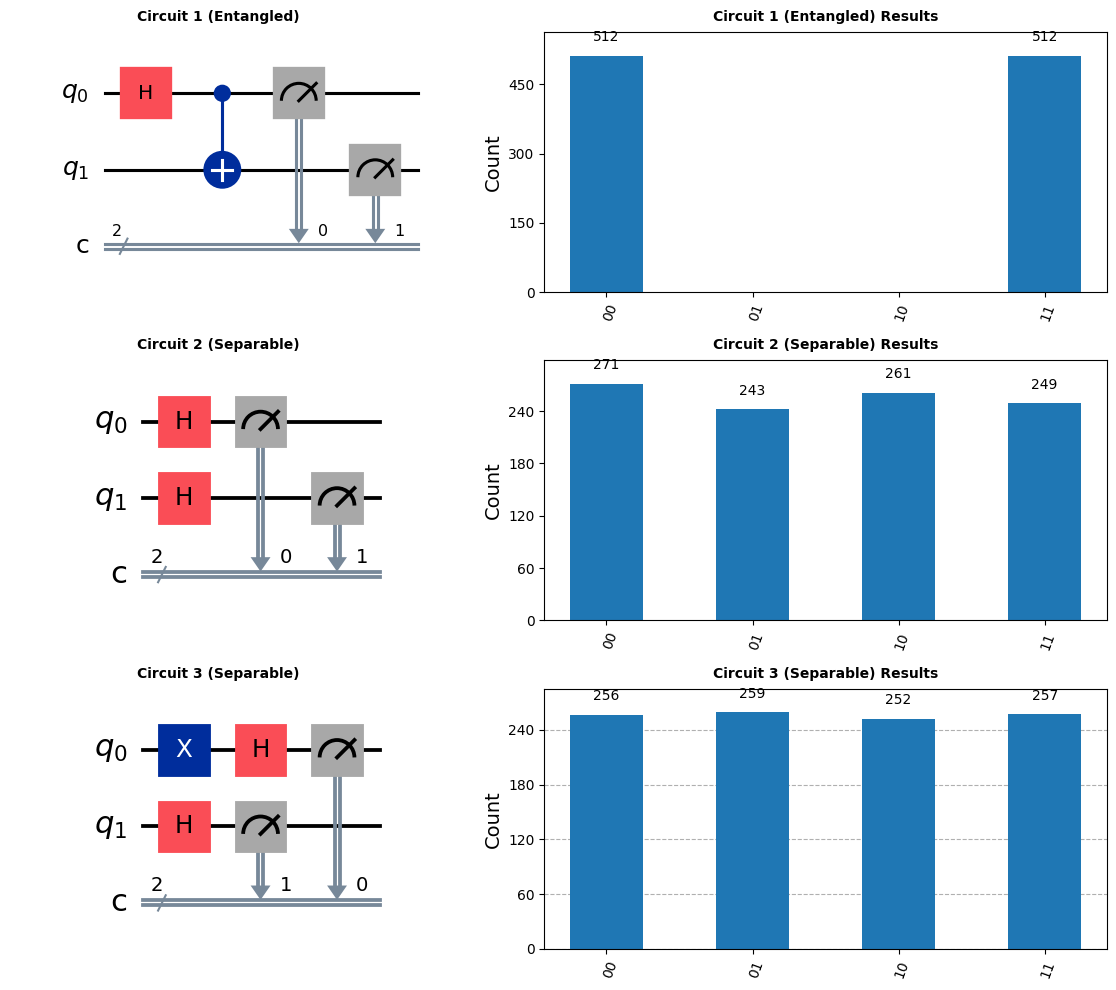

In [7]:
# ==============================================================================
# ASSIGNMENT: QUANTUM GATES, CIRCUITS & ENTANGLEMENT
# Framework: Qiskit | Shots: 1024
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

# Inicialización del simulador cuántico local de Qiskit Aer
sim = AerSimulator()


def complete_counts(counts, num_qubits):
    """Garantiza que todos los estados posibles de la base (2^n) aparezcan

    en el histograma de medición, asignando 0 a los estados no observados.
    """
    num_states = 2**num_qubits
    all_states = [f"{i:0{num_qubits}b}" for i in range(num_states)]
    return {state: counts.get(state, 0) for state in all_states}


# ==============================================================================
# 1. SINGLE-QUBIT GATE ORDER
# Investigación sobre cómo el orden de aplicación de las compuertas cuánticas
# afecta la evolución del estado final en un cúbit individual.
# ==============================================================================

# --- Circuito A: H -> X -> Z ---
qc_a = QuantumCircuit(1, 1)
qc_a.h(0)
qc_a.x(0)
qc_a.z(0)
sv_a = Statevector.from_instruction(qc_a)  # Cálculo del vector de estado teórico

qc_a_meas = qc_a.copy()
qc_a_meas.measure(0, 0)
counts_a = sim.run(qc_a_meas, shots=1024).result().get_counts()
counts_a_full = complete_counts(counts_a, 1)

# --- Circuito B: Z -> X -> H ---
qc_b = QuantumCircuit(1, 1)
qc_b.z(0)
qc_b.x(0)
qc_b.h(0)
sv_b = Statevector.from_instruction(qc_b)  # Cálculo del vector de estado teórico

qc_b_meas = qc_b.copy()
qc_b_meas.measure(0, 0)
counts_b = sim.run(qc_b_meas, shots=1024).result().get_counts()
counts_b_full = complete_counts(counts_b, 1)

# Presentación de resultados numéricos en formato Markdown
display(
    Markdown(
        f"""
### 📊 1. Single-Qubit Gate Order Comparison

* **Circuit A $(H \\rightarrow X \\rightarrow Z)$**
  * **Statevector:** `{list(np.round(sv_a.data, 4))}`
  * **Counts:** `{counts_a_full}`

* **Circuit B $(Z \\rightarrow X \\rightarrow H)$**
  * **Statevector:** `{list(np.round(sv_b.data, 4))}`
  * **Counts:** `{counts_b_full}`
---
"""
    )
)

# Renderizado del panel de circuitos e histogramas
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Fila 1: Circuito A
qc_a_meas.draw("mpl", ax=axes[0, 0])
axes[0, 0].set_title(
    "Circuit A: H $\\rightarrow$ X $\\rightarrow$ Z",
    fontsize=11,
    fontweight="bold",
    pad=10,
)
plot_histogram(counts_a_full, ax=axes[0, 1], color="#1f77b4")
axes[0, 1].set_title(
    "Circuit A Results", fontsize=11, fontweight="bold", pad=10
)

# Fila 2: Circuito B
qc_b_meas.draw("mpl", ax=axes[1, 0])
axes[1, 0].set_title(
    "Circuit B: Z $\\rightarrow$ X $\\rightarrow$ H",
    fontsize=11,
    fontweight="bold",
    pad=10,
)
plot_histogram(counts_b_full, ax=axes[1, 1], color="#1f77b4")
axes[1, 1].set_title(
    "Circuit B Results", fontsize=11, fontweight="bold", pad=10
)

plt.tight_layout()
plt.show()


# ==============================================================================
# 2. DESIGN YOUR OWN QUANTUM CIRCUIT
# Diseño de un circuito propio de monocúbit utilizando al menos 4 compuertas
# y repitiendo al menos una operación (Secuencia: H -> X -> H -> T).
# ==============================================================================

qc_own = QuantumCircuit(1, 1)
qc_own.h(0)
qc_own.x(0)
qc_own.h(0)
qc_own.t(0)

# Obtención del vector de estado sin colapsar
sv_own = Statevector.from_instruction(qc_own)

# Aplicación de medición para 1024 ejecuciones (shots)
qc_own_meas = qc_own.copy()
qc_own_meas.measure(0, 0)
counts_own = sim.run(qc_own_meas, shots=1024).result().get_counts()
counts_own_full = complete_counts(counts_own, 1)

display(
    Markdown(
        f"""
### 📊 2. Custom Single-Qubit Circuit

* **Gate Sequence:** $H \\rightarrow X \\rightarrow H \\rightarrow T$
* **Statevector:** `{list(np.round(sv_own.data, 4))}`
* **Measurement Counts:** `{counts_own_full}`
---
"""
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

qc_own_meas.draw("mpl", ax=axes[0])
axes[0].set_title(
    "Custom Circuit Diagram", fontsize=11, fontweight="bold", pad=10
)

plot_histogram(counts_own_full, ax=axes[1], color="#1f77b4")
axes[1].set_title(
    "Measurement Results (1024 Shots)", fontsize=11, fontweight="bold", pad=10
)

plt.tight_layout()
plt.show()


# ==============================================================================
# 3. INVESTIGATING TWO-QUBIT SYSTEMS
# Comparación entre una superposición independiente de 2 cúbits y un estado
# entrelazado mediante la aplicación de compuerta Hadamard y CNOT.
# ==============================================================================

# --- Circuito A: Superposición Independiente ---
qc_3a = QuantumCircuit(2, 2)
qc_3a.h(0)
qc_3a.h(1)
sv_3a = Statevector.from_instruction(qc_3a)

qc_3a_meas = qc_3a.copy()
qc_3a_meas.measure([0, 1], [0, 1])
counts_3a = sim.run(qc_3a_meas, shots=1024).result().get_counts()
counts_3a_full = complete_counts(counts_3a, 2)

# --- Circuito B: Estado Entrelazado ---
qc_3b = QuantumCircuit(2, 2)
qc_3b.h(0)
qc_3b.cx(0, 1)
sv_3b = Statevector.from_instruction(qc_3b)

qc_3b_meas = qc_3b.copy()
qc_3b_meas.measure([0, 1], [0, 1])
counts_3b = sim.run(qc_3b_meas, shots=1024).result().get_counts()
counts_3b_full = complete_counts(counts_3b, 2)

display(
    Markdown(
        f"""
### 📊 3. Two-Qubit Systems Comparison

* **Circuit A (Independent Superposition)**
  * **Statevector:** `{list(np.round(sv_3a.data, 4))}`
  * **Counts:** `{counts_3a_full}`

* **Circuit B (Entangled State)**
  * **Statevector:** `{list(np.round(sv_3b.data, 4))}`
  * **Counts:** `{counts_3b_full}`
---
"""
    )
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Circuito 3A
qc_3a_meas.draw("mpl", ax=axes[0, 0])
axes[0, 0].set_title(
    "Circuit A: Independent Superposition ($H_0, H_1$)",
    fontsize=11,
    fontweight="bold",
    pad=10,
)
plot_histogram(counts_3a_full, ax=axes[0, 1], color="#1f77b4")
axes[0, 1].set_title(
    "Circuit A Results", fontsize=11, fontweight="bold", pad=10
)

# Circuito 3B
qc_3b_meas.draw("mpl", ax=axes[1, 0])
axes[1, 0].set_title(
    "Circuit B: Entangled State ($H_0, CNOT_{0\\rightarrow 1}$)",
    fontsize=11,
    fontweight="bold",
    pad=10,
)
plot_histogram(counts_3b_full, ax=axes[1, 1], color="#1f77b4")
axes[1, 1].set_title(
    "Circuit B Results", fontsize=11, fontweight="bold", pad=10
)

plt.tight_layout()
plt.show()


# ==============================================================================
# 4. BELL STATE CHALLENGE
# Construcción del estado de Bell anti-correlacionado |Psi+> = (|01> + |10>)/sqrt(2)
# utilizando la inversión del estado inicial en q1.
# ==============================================================================

qc_psi_p = QuantumCircuit(2, 2)
qc_psi_p.x(1)  # Inicialización de q1 en |1> (estado combinado |10>)
qc_psi_p.h(0)  # Creación de superposición en el cúbit de control q0
qc_psi_p.cx(0, 1)  # Generación de entrelazamiento condicional CNOT

sv_psi_p = Statevector.from_instruction(qc_psi_p)

qc_psi_p_meas = qc_psi_p.copy()
qc_psi_p_meas.measure([0, 1], [0, 1])
counts_psi_p = sim.run(qc_psi_p_meas, shots=1024).result().get_counts()
counts_psi_p_full = complete_counts(counts_psi_p, 2)

display(
    Markdown(
        f"""
### 📊 4. Bell State Challenge ($|\\Psi^+\\rangle$)

* **Target Bell State:** $|\\Psi^+\\rangle = \\frac{{|01\\rangle + |10\\rangle}}{{\\sqrt{{2}}}}$
* **Statevector:** `{list(np.round(sv_psi_p.data, 4))}`
* **Measurement Counts:** `{counts_psi_p_full}`
---
"""
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

qc_psi_p_meas.draw("mpl", ax=axes[0])
axes[0].set_title(
    "Bell State $|\\Psi^+\\rangle$ Circuit",
    fontsize=11,
    fontweight="bold",
    pad=10,
)

plot_histogram(counts_psi_p_full, ax=axes[1], color="#1f77b4")
axes[1].set_title(
    "Measurement Results (1024 Shots)", fontsize=11, fontweight="bold", pad=10
)

plt.tight_layout()
plt.show()


# ==============================================================================
# 5. EXPLORE THE FOUR BELL STATES
# Implementación y caracterización sistemática de los cuatro estados
# de entrelazamiento máximo (Base de Bell).
# ==============================================================================

bell_configs = [
    ("$|\\Phi^+\\rangle$", [("h", 0), ("cx", 0, 1)]),
    ("$|\\Phi^-\\rangle$", [("z", 0), ("h", 0), ("cx", 0, 1)]),
    ("$|\\Psi^+\\rangle$", [("x", 1), ("h", 0), ("cx", 0, 1)]),
    ("$|\\Psi^-\\rangle$", [("x", 1), ("z", 0), ("h", 0), ("cx", 0, 1)]),
]

display(Markdown("### 📊 5. Explore the Four Bell States\n---"))

fig, axes = plt.subplots(4, 2, figsize=(12, 13))

for idx, (label, gates) in enumerate(bell_configs):
    qc = QuantumCircuit(2, 2)
    for g in gates:
        if g[0] == "h":
            qc.h(g[1])
        elif g[0] == "x":
            qc.x(g[1])
        elif g[0] == "z":
            qc.z(g[1])
        elif g[0] == "cx":
            qc.cx(g[1], g[2])

    sv = Statevector.from_instruction(qc)

    qc_meas = qc.copy()
    qc_meas.measure([0, 1], [0, 1])
    counts = sim.run(qc_meas, shots=1024).result().get_counts()
    counts_full = complete_counts(counts, 2)

    sv_rounded = list(np.round(sv.data, 3))
    display(
        Markdown(
            f"**State {label}:** Statevector = `{sv_rounded}` | Counts = `{counts_full}`"
        )
    )

    qc_meas.draw("mpl", ax=axes[idx, 0])
    axes[idx, 0].set_title(
        f"Circuit {label}", fontsize=10, fontweight="bold", pad=8
    )

    plot_histogram(counts_full, ax=axes[idx, 1], color="#1f77b4")
    axes[idx, 1].set_title(
        f"Results {label}", fontsize=10, fontweight="bold", pad=8
    )

plt.tight_layout()
plt.show()


# ==============================================================================
# 6. ENTANGLEMENT DETECTIVE
# Evaluación de tres circuitos para diagnosticar la presencia de entrelazamiento
# según el soporte matemático de los vectores de estado y su factorabilidad.
# ==============================================================================

detective_setups = [
    ("Circuit 1 (Entangled)", [("h", 0), ("cx", 0, 1)]),
    ("Circuit 2 (Separable)", [("h", 0), ("h", 1)]),
    ("Circuit 3 (Separable)", [("x", 0), ("h", 0), ("h", 1)]),
]

display(Markdown("### 📊 6. Entanglement Detective Investigation\n---"))

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for idx, (title, gates) in enumerate(detective_setups):
    qc = QuantumCircuit(2, 2)
    for g in gates:
        if g[0] == "h":
            qc.h(g[1])
        elif g[0] == "x":
            qc.x(g[1])
        elif g[0] == "cx":
            qc.cx(g[1], g[2])

    sv = Statevector.from_instruction(qc)

    qc_meas = qc.copy()
    qc_meas.measure([0, 1], [0, 1])
    counts = sim.run(qc_meas, shots=1024).result().get_counts()
    counts_full = complete_counts(counts, 2)

    display(
        Markdown(
            f"**{title}:** Statevector = `{list(np.round(sv.data, 3))}` | Counts = `{counts_full}`"
        )
    )

    qc_meas.draw("mpl", ax=axes[idx, 0])
    axes[idx, 0].set_title(title, fontsize=10, fontweight="bold", pad=8)

    plot_histogram(counts_full, ax=axes[idx, 1], color="#1f77b4")
    axes[idx, 1].set_title(
        f"{title} Results", fontsize=10, fontweight="bold", pad=8
    )

plt.tight_layout()
plt.show()

---

## 3. Two-Qubit Systems: Detailed Comparison & Analysis

### Circuit A: Independent Superposition
* **Mathematical Form:**  
  $$|\psi_A\rangle = (H \otimes H)|00\rangle = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)$$
* **Possible Measurement Outcomes:** `00`, `01`, `10`, `11` (each observing approximately $\approx 25\%$ probability).
* **State Classification:** **Separable State**.
* **Explanation & Proof:**  
  The joint statevector can be factored cleanly into the tensor product of two independent single-qubit statevectors:
  $$|\psi_A\rangle = |+\rangle_1 \otimes |+\rangle_0 = \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right) \otimes \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right)$$
  Because the state is factorizable, measuring $q_0$ collapses only its own wave function and provides zero information about the outcome of $q_1$.

---

### Circuit B: Entangled State
* **Mathematical Form:**  
  $$|\psi_B\rangle = CNOT_{0\rightarrow 1}(H \otimes I)|00\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$
* **Possible Measurement Outcomes:** `00` and `11` (each observing approximately $\approx 50\%$ probability). Outcomes `01` and `10` are strictly impossible ($0\%$ probability).
* **State Classification:** **Entangled State** (Maximally entangled Bell state $|\Phi^+\rangle$).
* **Explanation & Proof:**  
  The statevector cannot be expressed as a product of two individual single-qubit states. There exist no complex coefficients $a, b, c, d$ such that:
  $$(a|0\rangle + b|1\rangle) \otimes (c|0\rangle + d|1\rangle) = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$
  Expanding the LHS yields $ac|00\rangle + ad|01\rangle + bc|10\rangle + bd|11\rangle$. For $ad = 0$ and $bc = 0$ while $ac \neq 0$ and $bd \neq 0$ requires a mathematical contradiction. Thus, the qubits are entangled: measuring $q_0$ instantly dictates the state of $q_1$.

---

## 5. Theoretical Analysis & Phase vs. Probability

### The Four Bell States

The four Bell states form an orthonormal basis for a 2-qubit Hilbert space:

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}, \quad |\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}}$$

$$|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}, \quad |\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}$$

#### Why do $|\Phi^+\rangle$ and $|\Phi^-\rangle$ produce identical measurement probabilities?
Measurements in the computational basis project the quantum state vector onto $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$. By Born's rule, the probability of an outcome $|x\rangle$ is $P(x) = |\langle x | \psi \rangle|^2$.

For $|\Phi^+\rangle$, the amplitudes are $c_{00} = \frac{1}{\sqrt{2}}$ and $c_{11} = \frac{1}{\sqrt{2}}$, yielding $P(00) = 0.5$ and $P(11) = 0.5$.  
For $|\Phi^-\rangle$, the relative phase introduces a negative sign $c_{11} = -\frac{1}{\sqrt{2}}$. Taking the squared magnitude removes the phase factor $e^{i\pi} = -1$:

$$P(11) = \left|-\frac{1}{\sqrt{2}}\right|^2 = (-1)^2 \cdot \frac{1}{2} = 0.5$$

Consequently, both states produce identical probability distributions in the computational basis.

#### Relationship between $|\Psi^+\rangle$ and $|\Psi^-\rangle$
An identical relationship applies to $|\Psi^+\rangle$ and $|\Psi^-\rangle$. Both yield anti-correlated outcomes (`01` and `10` with $\approx 50\%$ probability). The relative phase difference of $\pi$ ($e^{i\pi} = -1$) present in $|\Psi^-\rangle$ drops out upon calculating squared magnitudes in the computational basis and can only be observed by measuring in non-computational bases (such as the $X$-basis).

---

## 6. Entanglement Detective Proofs

* **Circuit 1 (Entangled):**  
  The circuit $CNOT(H \otimes I)|00\rangle$ produces $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$. This state cannot be factored into single-qubit states, proving non-separability and maximal entangling dynamics due to the $CNOT$ operation.

* **Circuit 2 (Separable):**  
  The operation $(H \otimes H)|00\rangle$ yields $|++\rangle = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)$. This decomposes as $|+\rangle_0 \otimes |+\rangle_1$, indicating zero entanglement between qubits despite uniform probability distributions.

* **Circuit 3 (Separable):**  
  Applying $H$ to $q_1$ and $H \cdot X$ to $q_0$ produces the state $|-\rangle_0 \otimes |+\rangle_1 = \frac{1}{2}(|00\rangle + |01\rangle - |10\rangle - |11\rangle)$. Because the global state vector decomposes into independent single-qubit states, it is strictly separable.

---

## 7. Conceptual Questions

**Q1. What is the difference between a single-qubit superposition and a two-qubit entangled state?**  
A single-qubit superposition allows an isolated system to exist in a linear combination of its basis states ($a|0\rangle + b|1\rangle$), maintaining complete independence from other qubits. In contrast, a two-qubit entangled state describes a joint system whose global state vector cannot be factorized into individual single-qubit states ($|\psi\rangle \neq |\phi_1\rangle \otimes |\phi_2\rangle$), creating non-local correlations where measuring one qubit instantaneously determines the state of the other.

**Q2. What role does the CNOT gate play in creating a Bell state?**  
The CNOT gate acts as a conditional two-qubit entangling operation that maps computational product states into non-factorizable superpositions. When applied to a control qubit initialized in an equal superposition state ($\frac{|0\rangle + |1\rangle}{\sqrt{2}}$) and a target qubit, CNOT conditionally rotates the target qubit, coupling their basis states and generating maximal quantum entanglement.

**Q3. Why can two different quantum states produce the same computational-basis measurement probabilities?**  
Quantum measurements in the computational basis project the state vector onto basis states and evaluate probabilities defined by Born's rule ($P(x) = |c_x|^2$). Relative phase differences (such as the $-1$ relative phase in $|\Phi^-\rangle$ relative to $|\Phi^+\rangle$) drop out when evaluating squared magnitudes ($|-c_x|^2 = |c_x|^2$), causing distinct state vectors with phase variations to yield identical computational-basis measurement histograms.

**Q4. What is the difference between a Statevector and measurement counts in Qiskit?**  
A `Statevector` represents the exact, deterministic mathematical wave function in Hilbert space, retaining all complex probability amplitudes and phase information before measurement. Measurement counts represent the empirical, probabilistic frequency of collapsed classical outcomes collected after executing $N$ repeated experimental measurements (shots) on quantum hardware or simulators.

**Q5. How many computational-basis states are possible for $n$ qubits?**  
* **1 qubit:** $2^1 = 2$ basis states ($|0\rangle, |1\rangle$)
* **2 qubits:** $2^2 = 4$ basis states ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$)
* **3 qubits:** $2^3 = 8$ basis states
* **5 qubits:** $2^5 = 32$ basis states
* **n qubits:** $2^n$ basis states

*Relationship:* The dimension of the Hilbert space grows exponentially ($2^n$) with the number of qubits. Each additional qubit doubles the available state space dimensions through the tensor product structure ($\mathbb{C}^2 \otimes \mathbb{C}^2 \otimes \dots \otimes \mathbb{C}^2$).